In [1]:
# ── Cell 1 : Setup & Imports ──────────
import json
import pickle
import pathlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

project_root = next(
    p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
    if (p / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import marginal_comparison as mc

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 4)
print("Imports successful!")

Imports successful!


In [2]:
# ── Cell 2 : Locate Sibling Sampler Runs ──────────
# This notebook sits in a <chains>/<k>_comp/ folder and compares the NUTS, HMC and
# bayesm runs that live beside it: <sampler>/<run>/results/posterior_raw.pkl.

def _resolve_dir():
    nb = globals().get("__vsc_ipynb_file__")
    return pathlib.Path(nb).resolve().parent if nb else pathlib.Path.cwd()

XCOMP_DIR = _resolve_dir()
hits = sorted(XCOMP_DIR.glob("*/*/results/posterior_raw.pkl"))
if not hits:
    raise FileNotFoundError(
        f"No <sampler>/<run>/results/posterior_raw.pkl under:\n  {XCOMP_DIR}\n"
        f"This notebook must sit in a <chains>/<k>_comp/ folder. In VS Code set\n"
        f'  "jupyter.notebookFileRoot": "${{fileDirname}}"  and restart the kernel.'
    )

runs = {}
for h in hits:
    sampler = h.parents[2].name          # NUTS / HMC / bayesm
    runs.setdefault(sampler, h.parent)   # first run's results dir per sampler

meta = json.load(open(next(iter(runs.values())) / "meta.json"))
SCENARIO = meta["scenario"]
K_MODEL  = int(meta["k_model"])
K_TRUE   = int(meta["k_true"])
CHAINS   = int(meta["chains"])

print(f"x_comp folder : {XCOMP_DIR}")
print(f"scenario={SCENARIO}  K_MODEL={K_MODEL}  K_TRUE={K_TRUE}")
print(f"samplers found: {list(runs)}")

models = [mc.load_sampler(rd, name) for name, rd in runs.items()]
for m in models:
    print(f"  {m['name']:<8} mu {m['mu'].shape}")

x_comp folder : C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMultinomialLogit\hbmnl_mixture_experiments\1_chain\1_comp
scenario=1comp  K_MODEL=5  K_TRUE=1
samplers found: ['bayesm', 'HMC', 'NUTS', 'replication']


  bayesm   mu (1, 10000, 5, 4)
  HMC      mu (1, 10000, 5, 4)
  NUTS     mu (1, 10000, 5, 4)
  replication mu (1, 10000, 5, 4)


In [3]:
# ── Cell 3 : Ground Truth, Grids (Full + Chebyshev) & Trimmed Mass ──────────
# Two grids per parameter, used by all cells below; the True DGP only enters the
# envelopes and stays an overlay in the plots.
#   "Full"      - min/max envelope over every component of every sampler + True
#                 DGP; nothing excluded, can be very wide.
#   "Chebyshev" - each model's pooled-marginal mean +/- 5*std (exact moments via
#                 the law of total variance), so >= 96% of each model's marginal
#                 mass is guaranteed inside for any distribution.
# Trimmed-mass tables report the realised trim EXACTLY (mixture CDF, no grid
# error) - equal to the renormalisation each density receives in Cell 5. The
# window is symmetric in x, not in mass: the left/right split shows the skew.
raw = json.load(open(project_root / "data" / "simulated" / "mixture" / f"{SCENARIO}.json"))
P = int(raw["n_params"])
param_names = raw.get("param_names") or [f"Param_{i}" for i in range(P)]
true_model = mc.true_dgp_model(raw)

GRIDS = {
    "Full":                  mc.build_grids_full(models, true_model, n_grid=1000, n_sigma=6),
    "Chebyshev (k=5, >=96%)": mc.build_grids_chebyshev(models, true_model, n_grid=1000, k=5.0),
}
for label, grids in GRIDS.items():
    print(f"Grid extents [{label}]:")
    for j, pj in enumerate(param_names):
        print(f"  {pj:<10} [{grids[j][0]:+.2f}, {grids[j][-1]:+.2f}]")

for label, grids in GRIDS.items():
    trimmed = {m["name"]: (1.0 - mc.retained_mass(m, grids)) * 100.0
               for m in models + [true_model]}
    print(f"\nMass trimmed by the [{label}] window, in % of each marginal:")
    display(pd.DataFrame(trimmed, index=param_names).T.round(4))

cheb = GRIDS["Chebyshev (k=5, >=96%)"]
split = {}
for m in models + [true_model]:
    l, r = mc.trimmed_tails(m, cheb)
    split[m["name"]] = np.r_[l, r] * 100.0
cols = pd.MultiIndex.from_product([["left tail", "right tail"], param_names])
print("\nChebyshev trim by side, in % of each marginal:")
display(pd.DataFrame(split, index=cols).T.round(4))

Grid extents [Full]:
  Alt1       [-2300.97, +1463.81]
  Alt2       [-739.71, +574.15]
  Alt3       [-453.70, +432.59]
  Price      [-236.99, +267.19]
Grid extents [Chebyshev (k=5, >=96%)]:
  Alt1       [-14.10, +16.66]
  Alt2       [-8.89, +16.68]
  Alt3       [-6.38, +12.32]
  Price      [-10.45, +5.32]



Mass trimmed by the [Full] window, in % of each marginal:


,Alt1,Alt2,Alt3,Price
bayesm,0.0,0.0,0.0,0.0
HMC,0.0,0.0,0.0,0.0
NUTS,0.0,0.0,0.0,0.0
replication,0.0,0.0,0.0,0.0
True DGP,0.0,0.0,0.0,0.0



Mass trimmed by the [Chebyshev (k=5, >=96%)] window, in % of each marginal:


,Alt1,Alt2,Alt3,Price
bayesm,0.0385,0.0776,0.1822,0.2963
HMC,0.5348,0.2552,0.3373,0.5306
NUTS,0.3542,0.3705,0.4651,0.5415
replication,0.0336,0.0742,0.1888,0.4425
True DGP,0.0000,0.0000,0.0000,0.0000



Chebyshev trim by side, in % of each marginal:


left tail                         right tail                  \
                 Alt1    Alt2    Alt3   Price       Alt1    Alt2    Alt3   
bayesm         0.0246  0.0625  0.1397  0.1544     0.0139  0.0151  0.0426   
HMC            0.4243  0.1638  0.2256  0.3148     0.1105  0.0914  0.1118   
NUTS           0.2358  0.1954  0.3288  0.2854     0.1184  0.1751  0.1362   
replication    0.0221  0.0563  0.1444  0.3164     0.0115  0.0179  0.0444   
True DGP       0.0000  0.0000  0.0000  0.0000     0.0000  0.0000  0.0000   

                     
              Price  
bayesm       0.1418  
HMC          0.2157  
NUTS         0.2560  
replication  0.1261  
True DGP     0.0000

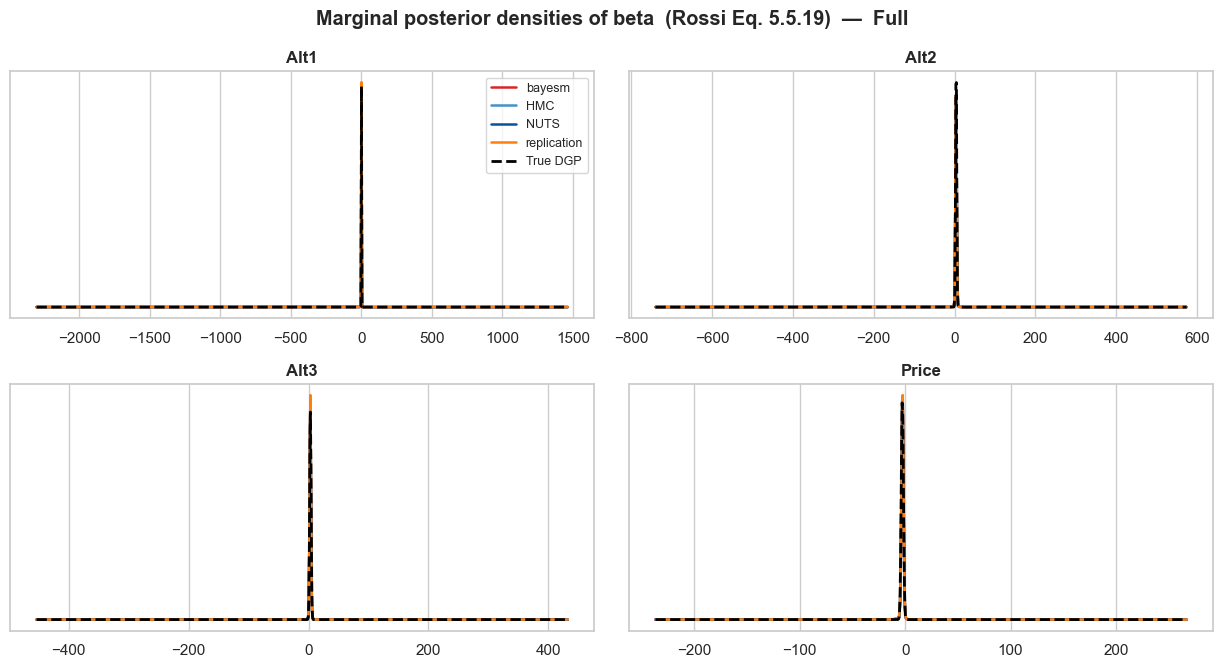

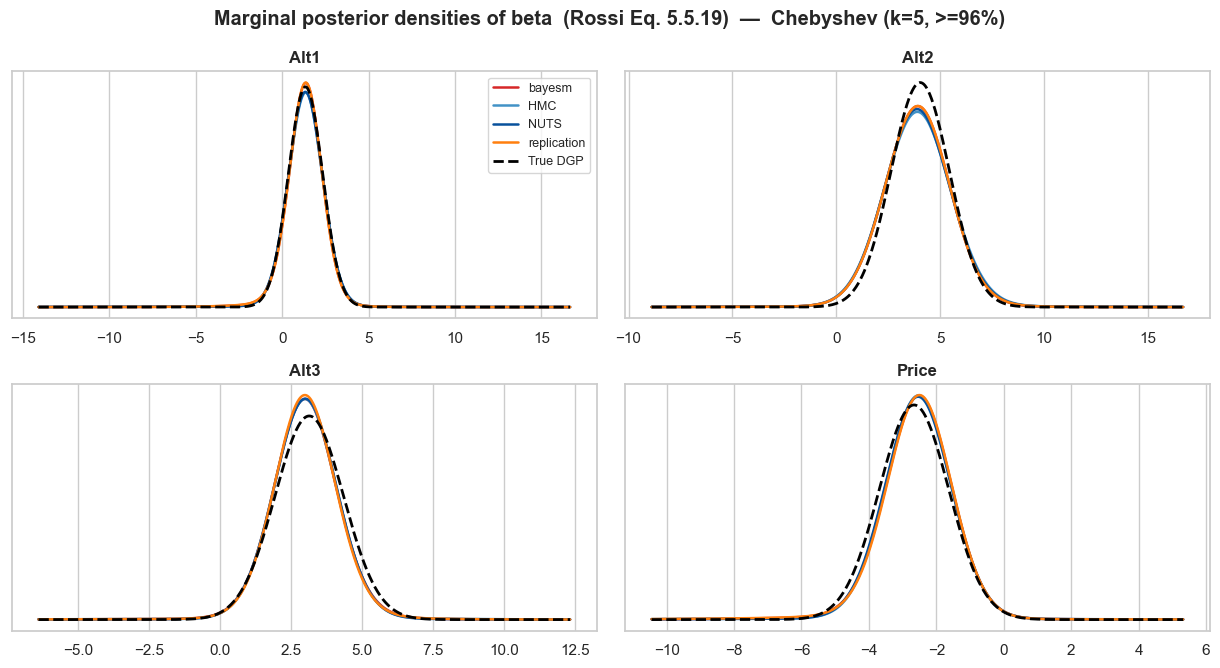

In [4]:
# ── Cell 4 : Marginal Densities (Rossi Eq. 5.5.19) - Full vs Chebyshev ──────────
# One figure per grid pass; True DGP dashed black, bayesm red, replication
# orange, Liesel gradient samplers in blues. Densities are cached in
# DENS/DENS_TRUE and reused by Cell 5.
colors = {"NUTS": "#08519c", "HMC": "#4292c6", "bayesm": "#d62728", "replication": "#ff7f0e"}
TRUE_COLOR = "#000000"
ncols = min(P, 2)
nrows = int(np.ceil(P / ncols))

DENS, DENS_TRUE = {}, {}
for label, grids in GRIDS.items():
    dens      = {m["name"]: mc.marginal_density(m, grids) for m in models}
    dens_true = mc.marginal_density(true_model, grids)
    DENS[label], DENS_TRUE[label] = dens, dens_true

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6.2, nrows * 3.4), squeeze=False)
    ax = axes.ravel()
    for j, pj in enumerate(param_names):
        for name, d in dens.items():
            ax[j].plot(grids[j], d[j], lw=1.8, label=name, color=colors.get(name, "#7f7f7f"))
        ax[j].plot(grids[j], dens_true[j], lw=2.0, ls="--", color=TRUE_COLOR, label="True DGP")
        ax[j].set_title(pj, fontweight="bold")
        ax[j].set_yticks([])
    for j in range(P, len(ax)):
        ax[j].set_visible(False)
    ax[0].legend(fontsize=9)
    fig.suptitle(f"Marginal posterior densities of beta  (Rossi Eq. 5.5.19)  —  {label}",
                 fontweight="bold")
    fig.tight_layout()
    plt.show()

In [5]:
# ── Cell 5 : Density Distances vs True DGP - Full vs Chebyshev ──────────
# Each sampler vs the True DGP only (never sampler-vs-sampler): Hellinger
# (primary), KL(model||true), JSD, TVD, Wasserstein-1. Reuses DENS/DENS_TRUE.
for label, grids in GRIDS.items():
    print(f"--- {label} ---")
    display(mc.distance_table(models, true_model, grids, param_names,
                               dens=DENS[label], dens_true=DENS_TRUE[label]))

--- Full ---


C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMultinomialLogit\src\marginal_comparison.py:316: RuntimeWarning: overflow encountered in divide
  term = np.where((a > 0) & (b > 0), a * np.log(a / np.where(b > 0, b, 1.0)), 0.0)


Hellinger       KL      JSD      TVD  Wasserstein1
sampler     param                                                    
bayesm      Alt1     0.06482      inf  0.00357  0.01517       0.07532
            Alt2     0.08373  0.12270  0.00636  0.06804       0.22674
            Alt3     0.07656      inf  0.00507  0.06219       0.17614
            Price    0.08796      inf  0.00639  0.06057       0.16857
HMC         Alt1     0.07530      inf  0.00430  0.01607       0.17764
            Alt2     0.09795  0.40236  0.00852  0.07892       0.30657
            Alt3     0.08479      inf  0.00606  0.06412       0.20246
            Price    0.09143      inf  0.00672  0.05849       0.19245
NUTS        Alt1     0.06717      inf  0.00347  0.01347       0.14954
            Alt2     0.09807  0.58325  0.00832  0.07591       0.32635
            Alt3     0.08666      inf  0.00623  0.06309       0.22657
            Price    0.08770      inf  0.00610  0.05346       0.18877
replication Alt1     0.06663      inf  0.00381  0.01611       0.07707
            Alt2     0.08385  0.11867  0.00635  0.06755       0.22464
            Alt3     0.08204      inf  0.00589  0.06843       0.18041
            Price    0.09843      inf  0.00791  0.06582       0.19037

--- Chebyshev (k=5, >=96%) ---


Hellinger       KL      JSD      TVD  Wasserstein1
sampler     param                                                    
bayesm      Alt1     0.07247  0.15740  0.00411  0.02295       0.06998
            Alt2     0.08140  0.06013  0.00609  0.06570       0.21241
            Alt3     0.07039  0.04782  0.00444  0.05953       0.15204
            Price    0.07914  0.07193  0.00537  0.06060       0.13820
HMC         Alt1     0.07499  0.30413  0.00419  0.01970       0.09569
            Alt2     0.09126  0.08011  0.00764  0.07639       0.23563
            Alt3     0.07424  0.05563  0.00490  0.06097       0.15201
            Price    0.07562  0.07171  0.00489  0.05715       0.13786
NUTS        Alt1     0.06783  0.24599  0.00346  0.01864       0.08571
            Alt2     0.08819  0.08429  0.00705  0.07200       0.23078
            Alt3     0.07207  0.05522  0.00462  0.05945       0.15142
            Price    0.07067  0.06550  0.00423  0.05207       0.12734
replication Alt1     0.07443  0.14795  0.00436  0.02411       0.07476
            Alt2     0.08162  0.06107  0.00610  0.06515       0.21060
            Alt3     0.07611  0.05309  0.00524  0.06580       0.15576
            Price    0.08654  0.09055  0.00638  0.06568       0.14770

In [6]:
# ── Cell 6 : Mixture Moments (Rossi Eq. 5.5.2) & Weights ──────────
# Grid-independent (analytic in the draws); runs once.
allm = models + [true_model]
mean_tbl = pd.DataFrame({m["name"]: mc.mixture_moments(m)[0] for m in allm}, index=param_names)
var_tbl  = pd.DataFrame({m["name"]: np.diag(mc.mixture_moments(m)[1]) for m in allm}, index=param_names)
print("E[theta]  (overall mixture mean):")
display(mean_tbl.round(3))
print("diag Var[theta]  (overall mixture variance):")
display(var_tbl.round(3))

E[theta]  (overall mixture mean):

,bayesm,HMC,NUTS,replication,True DGP
Alt1,1.301,1.227,1.279,1.295,1.349
Alt2,3.866,3.884,3.896,3.876,4.032
Alt3,2.989,2.991,2.968,2.987,3.141
Price,-2.565,-2.562,-2.561,-2.592,-2.659


diag Var[theta]  (overall mixture variance):


,bayesm,HMC,NUTS,replication,True DGP
Alt1,1.626,6.676,9.396,1.590,0.980
Alt2,3.039,5.582,6.497,3.030,1.974
Alt3,1.925,2.649,3.471,1.904,1.454
Price,1.788,2.283,2.471,2.069,1.063


In [7]:
# ── Cell 7 : Convergence of the Marginals - Goose-identical functional diagnostics ──────────
# az.rhat (rank) / az.ess (bulk, tail) - the exact calls in Goose's summary() -
# on grid-free functionals of each per-draw marginal: mean, sd, q05/q50/q95.
# ESS/s divides by the fit's total wall-clock (meta.json duration_s, incl.
# warmup). Read ESS only where R-hat ~ 1. Alternatives: mc.curve_diagnostics,
# mc.density_series_diagnostics.
if CHAINS == 1:
    print("NOTE: single chain -> split-chain diagnostics; WITHIN-chain checks only.\n")

for m in models:
    rt = m.get("duration_s")
    print(f"--- {m['name']}" + (f"  (fit wall-clock: {rt:,.0f}s)" if rt else "") + " ---")
    display(mc.functional_diagnostics(m, param_names).round(3))

NOTE: single chain -> split-chain diagnostics; WITHIN-chain checks only.

--- bayesm  (fit wall-clock: 264s) ---


Rhat  ESS_bulk  ESS_tail  ESS_bulk/s  ESS_tail/s
param functional                                                   
Alt1  mean        1.000   698.775  1700.008       2.643       6.430
      sd          1.003   658.353  1667.300       2.490       6.306
      q05         1.008   306.998   461.058       1.161       1.744
      q50         1.001   429.707   626.013       1.625       2.368
      q95         1.008   271.736   735.559       1.028       2.782
Alt2  mean        1.005   534.283  1776.235       2.021       6.718
      sd          1.002  1048.190  2063.037       3.964       7.803
      q05         1.001  1213.485  2683.740       4.590      10.150
      q50         1.010   427.587   748.320       1.617       2.830
      q95         1.001   304.393   408.939       1.151       1.547
Alt3  mean        1.001   527.081  1950.565       1.993       7.377
      sd          1.003   640.359  1439.240       2.422       5.443
      q05         1.006   583.273  1962.154       2.206       7.421
      q50         1.002   535.224  1673.582       2.024       6.330
      q95         1.006   213.257   359.167       0.807       1.358
Price mean        1.006   224.335   707.175       0.848       2.675
      sd          1.001   291.479  1048.302       1.102       3.965
      q05         1.005   121.003   219.666       0.458       0.831
      q50         1.004   730.446  2682.979       2.763      10.147
      q95         1.000  1696.800  4430.672       6.418      16.757

--- HMC  (fit wall-clock: 296s) ---


Rhat  ESS_bulk  ESS_tail  ESS_bulk/s  ESS_tail/s
param functional                                                   
Alt1  mean        1.186     7.866    37.108       0.027       0.125
      sd          1.101    14.553   206.695       0.049       0.698
      q05         1.029   130.627   450.818       0.441       1.521
      q50         1.032    78.011   149.180       0.263       0.503
      q95         1.016    86.846   324.551       0.293       1.095
Alt2  mean        1.037    73.516    52.578       0.248       0.177
      sd          1.007   306.872   250.274       1.036       0.845
      q05         1.034   126.574   431.514       0.427       1.456
      q50         1.042    63.887    32.857       0.216       0.111
      q95         1.015    88.691   155.008       0.299       0.523
Alt3  mean        1.013    83.207   333.911       0.281       1.127
      sd          1.005   326.282   604.483       1.101       2.040
      q05         1.012   236.926   779.964       0.800       2.632
      q50         1.027    77.529   232.903       0.262       0.786
      q95         1.032    57.533   257.334       0.194       0.868
Price mean        1.011    81.932   297.116       0.277       1.003
      sd          1.004   214.423   705.472       0.724       2.381
      q05         1.018    71.899   133.273       0.243       0.450
      q50         1.012   207.936   753.557       0.702       2.543
      q95         1.005   451.583  3349.755       1.524      11.305

--- NUTS  (fit wall-clock: 910s) ---


Rhat  ESS_bulk  ESS_tail  ESS_bulk/s  ESS_tail/s
param functional                                                   
Alt1  mean        1.015   163.541   317.740       0.180       0.349
      sd          1.008   245.117   609.914       0.269       0.670
      q05         1.004   554.809  1013.545       0.609       1.113
      q50         1.010   224.257    96.774       0.246       0.106
      q95         1.002   286.419   810.070       0.315       0.890
Alt2  mean        1.053    34.268   135.546       0.038       0.149
      sd          1.019   175.648   438.957       0.193       0.482
      q05         1.003  1472.585  3245.348       1.617       3.564
      q50         1.011   283.778   440.914       0.312       0.484
      q95         1.018   286.949  1330.837       0.315       1.462
Alt3  mean        1.010   221.408   598.501       0.243       0.657
      sd          1.029   165.683   781.654       0.182       0.858
      q05         1.005  1122.776  2252.584       1.233       2.474
      q50         1.009   297.550  1040.837       0.327       1.143
      q95         1.004   485.112  1378.469       0.533       1.514
Price mean        1.050    41.387   250.894       0.045       0.276
      sd          1.019   167.581   757.244       0.184       0.832
      q05         1.030   100.718   410.282       0.111       0.451
      q50         1.004   424.182   627.226       0.466       0.689
      q95         1.012   675.712  4237.025       0.742       4.654

--- replication  (fit wall-clock: 179s) ---


Rhat  ESS_bulk  ESS_tail  ESS_bulk/s  ESS_tail/s
param functional                                                   
Alt1  mean        1.006   565.670  1549.846       3.167       8.678
      sd          1.001   737.476  1522.008       4.129       8.522
      q05         1.007   392.585   881.823       2.198       4.937
      q50         1.011   481.978  1174.288       2.699       6.575
      q95         1.004   354.112   844.993       1.983       4.731
Alt2  mean        1.010   734.727  2638.837       4.114      14.775
      sd          1.004   839.929  2142.655       4.703      11.997
      q05         1.002  1250.614  2811.065       7.002      15.739
      q50         1.009   649.958  2163.998       3.639      12.116
      q95         1.010   426.023   901.967       2.385       5.050
Alt3  mean        1.022   460.873  1567.747       2.580       8.778
      sd          1.004   669.231  1770.934       3.747       9.916
      q05         1.006   758.398  1480.831       4.246       8.291
      q50         1.009   577.353  1905.774       3.233      10.671
      q95         1.045    81.784   636.252       0.458       3.562
Price mean        1.024    78.642   520.552       0.440       2.915
      sd          1.019    83.655   288.695       0.468       1.616
      q05         1.022   201.079   341.055       1.126       1.910
      q50         1.004   870.435  2831.203       4.874      15.852
      q95         1.000  1625.547  6039.976       9.102      33.818

In [8]:
# ── Cell 8 : Notes ──────────
print("Notes:")
print(" - All quantities are label-invariant: relabeling/ECR would not change them.")
print(" - Grids: 'Full' = unbounded envelope over every component + True DGP;")
print("   'Chebyshev (k=5)' = each model's mixture mean +/- 5*std (>=96% mass).")
print(" - Cell 7: Goose-identical arviz diagnostics (rank split-R-hat, bulk/tail")
print("   ESS) on grid-free functionals of each per-draw marginal.")
print(" - 1-chain runs: chains split into halves - a within-chain check only.")
print("   bayesm's seed-based chains are not over-dispersed (weaker R-hat test).")

Notes:
 - All quantities are label-invariant: relabeling/ECR would not change them.
 - Grids: 'Full' = unbounded envelope over every component + True DGP;
   'Chebyshev (k=5)' = each model's mixture mean +/- 5*std (>=96% mass).
 - Cell 7: Goose-identical arviz diagnostics (rank split-R-hat, bulk/tail
   ESS) on grid-free functionals of each per-draw marginal.
 - 1-chain runs: chains split into halves - a within-chain check only.
   bayesm's seed-based chains are not over-dispersed (weaker R-hat test).
